# Insights from Failed Orders

# Business Info
- Gett, previously known as GetTaxi, is an Israeli-developed 
technology platform solely focused on corporate Ground Transportation
Management (GTM). They have an application where clients can order 
taxis, and drivers can accept their rides (offers). 
At the moment, when the client clicks the Order button in 
the application, the matching system searches for the most 
    relevant drivers and offers them the order. In this task, we would like 
to investigate some matching metrics for orders that did not completed 
successfully, i.e., the customer didn't end up getting a car.

# Assignment

Please complete the following tasks:

---

## 1. Distribution of Orders by Reason for Failure

- Build a distribution of orders categorized by:
  - Cancellations **before** driver assignment
  - Cancellations **after** driver assignment
  - Rejections (cancelled by system)
  
- **Analyse** the resulting plot:
  - Which category has the highest number of failed orders?

---

## 2. Distribution of Failed Orders by Hour

- Plot the **distribution of failed orders by hour of the day**.
- Investigate trends:
  - Are there specific hours with an abnormally high proportion of a failure category?
  - What hours are the "biggest fails"?
  - How can this be explained?

---

## 3. Average Time to Cancellation by Hour

- Plot the **average cancellation time (in seconds)**:
  - Separate plots or lines for cancellations **with** and **without** a driver.
  - Group by **hour of the day**.
  
- **Remove outliers** if they affect the clarity of the plot.

- Try to **draw conclusions** from the resulting trends.

---

## 4. Distribution of Average ETA by Hour

- Plot the **distribution of average ETA (m_order_eta)** grouped by hour.
- **Interpret** the results:
  - How can this plot be explained?

---




# Data Description

We have two datasets: `data_orders` and `data_offers`, both stored in CSV format.

---

## `data_orders`

This dataset contains the following columns:

- **order_datetime**  
  Time of the order.

- **origin_longitude**  
  Longitude of the order's origin.

- **origin_latitude**  
  Latitude of the order's origin.

- **m_order_eta**  
  Estimated time of arrival (in minutes).

- **order_gk**  
  Order number (unique identifier).

- **order_status_key**  
  Status of the order. The values map to:
  - `4` – Cancelled by client  
  - `9` – Cancelled by system (rejected)

- **is_driver_assigned_key**  
  Indicates whether a driver was assigned to the order.

- **cancellation_time_in_seconds**  
  Number of seconds passed before the order was cancelled.

---

## `data_offers`

This dataset is a simple map with the following columns:

- **order_gk**  
  Order number (linked to `data_orders.order_gk`).

- **offer_id**  
  ID of the offer made for the order.


In [107]:
#Import necessary libraries 
import numpy as np 
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import datetime as dt

In [115]:
offers = pd.read_csv('data_offers.csv')
orders = pd.read_csv('data_orders.csv')
offers.head()

,order_gk,offer_id
0,3000579625629,300050936206
1,3000627306450,300052064651
2,3000632920686,300052408812
3,3000632771725,300052393030
4,3000583467642,300051001196


In [117]:
orders.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0
1,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0
2,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0
3,13:50:20,-1.054671,51.460544,658.0,3000582941169,4,1,62.0
4,21:24:45,-0.967605,51.458236,NaN,3000583140877,9,0,NaN


In [119]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10716 entries, 0 to 10715
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_datetime                 10716 non-null  object 
 1   origin_longitude               10716 non-null  float64
 2   origin_latitude                10716 non-null  float64
 3   m_order_eta                    2814 non-null   float64
 4   order_gk                       10716 non-null  int64  
 5   order_status_key               10716 non-null  int64  
 6   is_driver_assigned_key         10716 non-null  int64  
 7   cancellations_time_in_seconds  7307 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 669.9+ KB


In [121]:
#rows and columns of the dataframes
orders.shape,  offers.shape

((10716, 8), (334363, 2))

In [123]:
#inner merge the the two dataframes 
df = orders.merge(right=offers, how='inner', on='order_gk')

In [125]:
df.sample(n=10, random_state=42)

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds,offer_id
30194,21:15:35,-0.969588,51.455780,299.0,3000555697076,4,1,223.0,300050725946
14748,10:13:35,-0.955958,51.430362,NaN,3000626091676,4,0,91.0,300052014519
29083,09:16:38,-1.033560,51.441967,NaN,3000594099225,4,0,68.0,300051458740
16926,02:08:09,-0.967676,51.444489,NaN,3000626980467,4,0,125.0,300052031394
21530,21:44:21,-0.972683,51.456762,NaN,3000554421440,4,0,11.0,300050671163
13008,03:03:45,-0.966745,51.453236,NaN,3000593295623,9,0,NaN,300051413313
2034,14:41:22,-0.948642,51.449587,NaN,3000584916226,4,0,6.0,300051090742
2229,20:54:03,-0.991382,51.476339,NaN,3000585716553,9,0,NaN,300051125957
16632,18:06:17,-0.948907,51.444643,NaN,3000627382471,4,0,113.0,300052078801
18189,07:52:29,-0.973793,51.458665,479.0,3000587781360,4,1,47.0,300051178628


- order_gk values needs to be readable and understandable for users because 4 means cancelled by client and 9 means rejected by system so it would be better to assign the values to a better values that is readable
- is_driver_assigned_key also needs to be easily readable by users so assigning 0 = False and 1 = True would be better 

In [128]:
#creating new comprehensive columns for order_status_key and is_driver_assigned_key
df['is_driver_assigned'] = np.where(df['is_driver_assigned_key'] == 1, 'Yes', 'No')
df['order_status'] = np.where(df['order_status_key'] == 4, 'Client Cancelled','System Reject')

In [130]:
#dropping the columns the key columns because we have a readable new column representing the numerical values
df.drop(columns=['is_driver_assigned_key', 'order_status_key'], inplace=True)

In [136]:
#CHANGING order datetime column to datetime data-type
df['order_datetime'] = pd.to_datetime(df['order_datetime'])

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31268 entries, 0 to 31267
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_datetime                 31268 non-null  datetime64[ns]
 1   origin_longitude               31268 non-null  float64       
 2   origin_latitude                31268 non-null  float64       
 3   m_order_eta                    8364 non-null   float64       
 4   order_gk                       31268 non-null  int64         
 5   cancellations_time_in_seconds  21795 non-null  float64       
 6   offer_id                       31268 non-null  int64         
 7   is_driver_assigned             31268 non-null  object        
 8   order_status                   31268 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 2.1+ MB


In [140]:
df

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,cancellations_time_in_seconds,offer_id,is_driver_assigned,order_status
0,2025-07-16 18:08:07,-0.978916,51.456173,60.0,3000583041974,198.0,300050983403,Yes,Client Cancelled
1,2025-07-16 20:57:32,-0.950385,51.456843,NaN,3000583116437,128.0,300050986179,No,Client Cancelled
2,2025-07-16 20:57:32,-0.950385,51.456843,NaN,3000583116437,128.0,300050986174,No,Client Cancelled
3,2025-07-16 20:57:32,-0.950385,51.456843,NaN,3000583116437,128.0,300050986180,No,Client Cancelled
4,2025-07-16 12:07:50,-0.969520,51.455544,477.0,3000582891479,46.0,300050976275,Yes,Client Cancelled
...,...,...,...,...,...,...,...,...,...
31263,2025-07-16 12:44:11,-0.975372,51.457846,NaN,3000597886155,43.0,300051590196,No,Client Cancelled
31264,2025-07-16 12:42:52,-0.975372,51.457846,NaN,3000597886140,44.0,300051590176,No,Client Cancelled
31265,2025-07-16 13:11:35,-0.975372,51.457846,NaN,3000599186906,36.0,300051648809,No,Client Cancelled
31266,2025-07-16 13:17:21,-0.972926,51.457693,60.0,3000599187034,34.0,300051648910,Yes,Client Cancelled


# Assignment 1 
* Build up distribution of orders according to reasons for failure: cancellations before and after driver assignment, and reasons for order rejection. Analyse the resulting plot. 
Which category has the highest number of orders?

In [33]:
#grouping the dataframe by 'is_driver_assigned' and 'order_status'.
df.groupby(by=['is_driver_assigned', 'order_status'])['offer_id'].count()

is_driver_assigned  order_status    
No                  Client Cancelled    13435
                    System Reject        9469
Yes                 Client Cancelled     8360
                    System Reject           4
Name: offer_id, dtype: int64

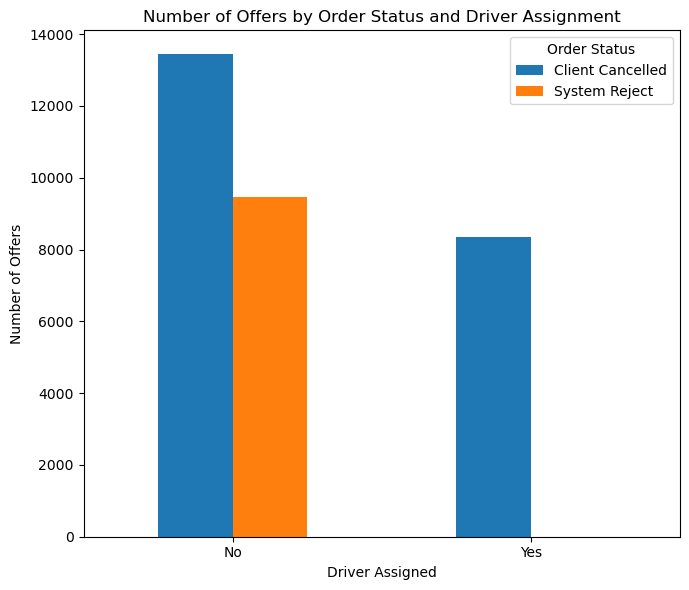

In [144]:
#plotting the series data
import matplotlib.pyplot as plt

# Prepare the data
grouped_df = df.groupby(['is_driver_assigned', 'order_status'])['offer_id'].count().unstack()

# Plot
grouped_df.plot(kind='bar', figsize=(7, 6))
plt.title('Number of Offers by Order Status and Driver Assignment')
plt.xlabel('Driver Assigned')
plt.ylabel('Number of Offers')
plt.xticks(rotation=0)
plt.legend(title='Order Status')
plt.tight_layout()
plt.show()



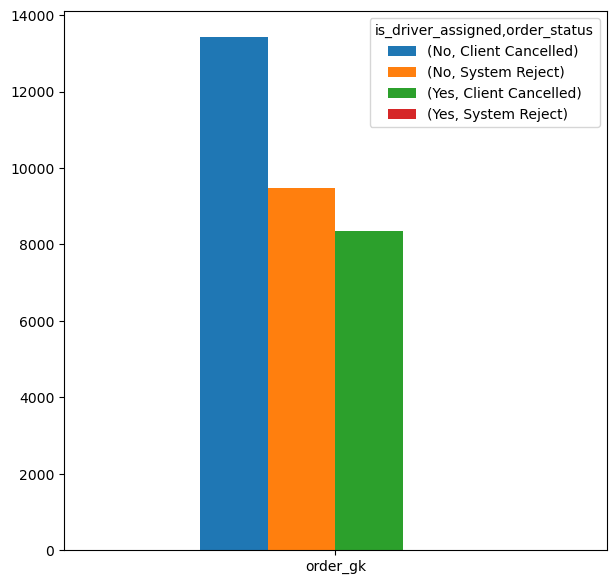

In [146]:
df_q1 = df.pivot_table(columns=["is_driver_assigned", "order_status"], values="order_gk", aggfunc="count")
_ = df_q1.plot(kind="bar", subplots=False, figsize=(7, 7), legend=True, rot=0)

- Orders that werent assigned by any driver/(before they were assigned by a driver) and was cancelled by client had the most orders of 13435 possibly due to change of plans or dissatisfaction with estimated arrival times (ETA).

# Assignment 2
Plot the distribution of failed orders by hours. Is there a trend that certain hours have an abnormally high proportion of one category or another? What hours are the biggest fails? How can this be explained?

In [152]:
#change the order_datetime to hours values
df['order_datetime'] = pd.DatetimeIndex(df['order_datetime']).hour.astype(int)

In [154]:
#group the hours values
hour = df.groupby(by=['order_datetime'])

In [156]:
hh = hour[['order_status']].count().sort_values(by='order_datetime', ascending=True)
hh

,order_status
order_datetime,
0,1993
1,1305
2,1475
3,1418
4,227
5,111
6,392
7,1566
8,3865


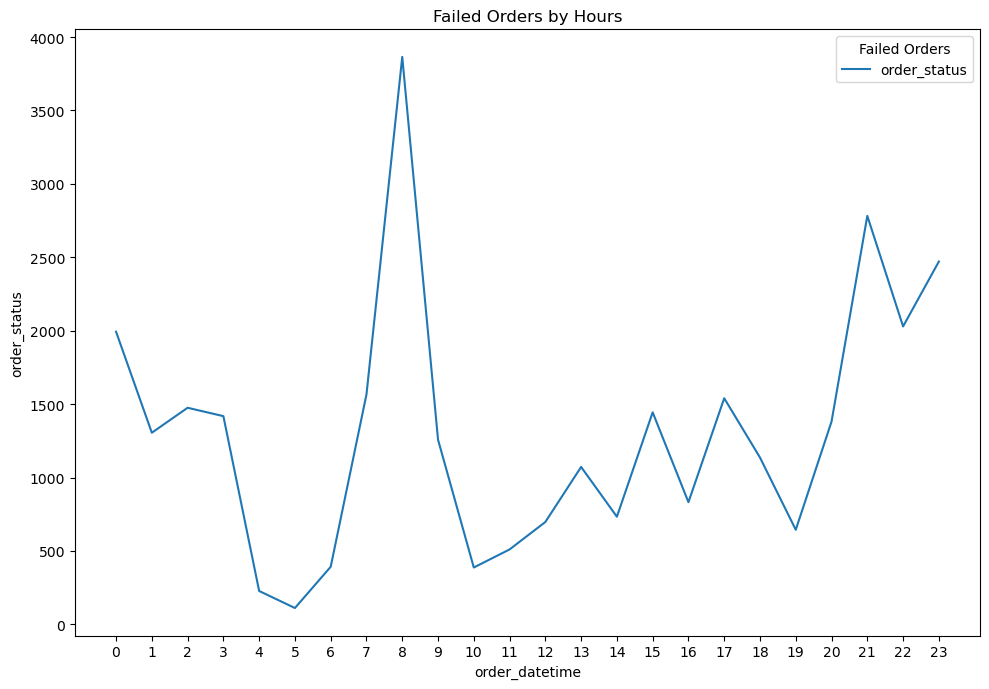

In [49]:
#Plotting the graph
hh.plot(kind='line', figsize=(10,7), xticks=range(0,24))
plt.xlabel('order_datetime')
plt.ylabel('order_status')
plt.title('Failed Orders by Hours')
plt.legend(title='Failed Orders')
plt.tight_layout()
plt.show()
          

- From the above graph we can see that most order were cancelled at 8 am 
- Lets check also order cancellation by various categories

In [167]:
#group by various categories
hour_status = df.groupby(by=['order_datetime','is_driver_assigned','order_status'])
hs = hour_status['order_gk'].count().sort_values(ascending=True)
hs

order_datetime  is_driver_assigned  order_status    
0               Yes                 System Reject          4
5               No                  Client Cancelled      31
                                    System Reject         33
10              No                  System Reject         37
4               No                  System Reject         45
                                                        ... 
8               Yes                 Client Cancelled    1080
23              No                  Client Cancelled    1144
8               No                  System Reject       1338
21              No                  Client Cancelled    1421
8               No                  Client Cancelled    1447
Name: order_gk, Length: 73, dtype: int64

In [169]:
#create a pivot table for the grouped categorical features
hs_table = hs.reset_index().pivot(index='order_datetime',
                           columns=['is_driver_assigned','order_status'],
                                  values='order_gk')
hs_table.head()

is_driver_assigned           Yes               No                \
order_status       System Reject Client Cancelled System Reject   
order_datetime                                                    
0                            4.0            957.0         706.0   
1                            NaN            633.0         374.0   
2                            NaN            586.0         649.0   
3                            NaN            565.0         658.0   
4                            NaN             90.0          45.0   

is_driver_assigned              Yes  
order_status       Client Cancelled  
order_datetime                       
0                             326.0  
1                             298.0  
2                             240.0  
3                             195.0  
4                              92.0

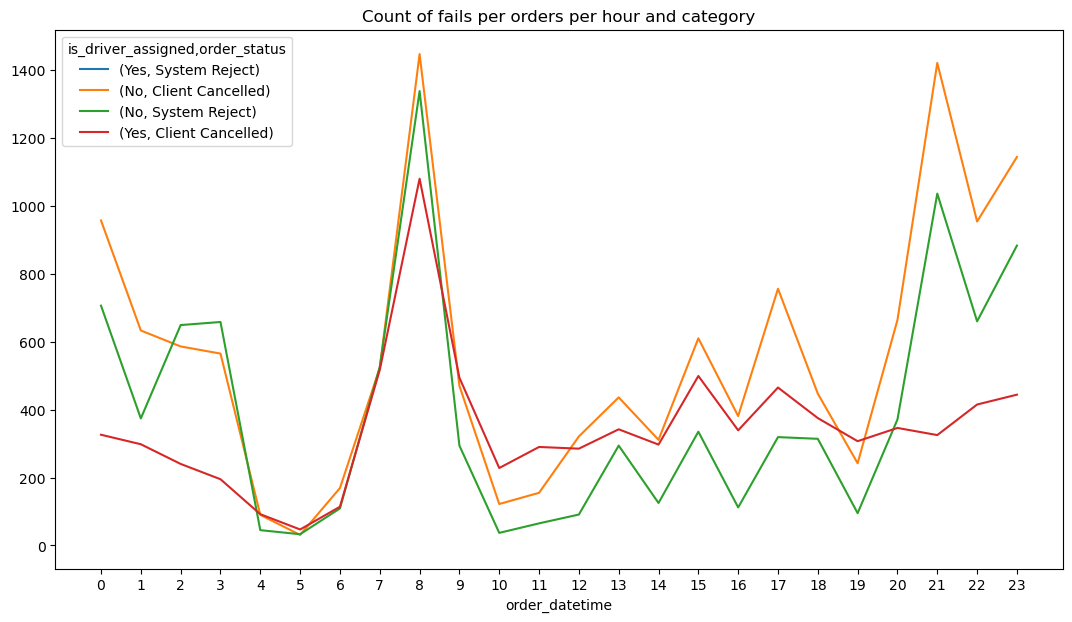

In [171]:
#Plot the graph for the pivot table 
hs_table.plot(xticks=range(0,24), 
                  figsize=(13,7),
                title='Count of fails per orders per hour and category');

- From the above line chart we can see that other timeframes has more cancelled orders 
than the others. We can conclude that orders which wasnt assigned by a driver and 
got cancelled by the client has majority number orders at 8 am and 21 pm in comparison to orders which was assigned by a driver and still got cancelled.

- During early morning hours (0–6 AM), system rejections and pre-assignment cancellations dominate, likely due to low driver availability.

- Around 11 AM, there is a clear spike in cancellations after driver assignment, possibly due to traffic delays or customers no longer needing the ride.

- Between 6 PM and 9 PM, cancellations before assignment rise sharply — likely a result of high demand and slower driver response times.


## Assignment 3 

Plot the average time to cancellation with and without driver, by the hour. If there are any outliers in the data, it would be better to remove them. Can we draw any conclusions from this plot?

In [60]:
df

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,cancellations_time_in_seconds,offer_id,is_driver_assigned,order_status
0,18,-0.978916,51.456173,60.0,3000583041974,198.0,300050983403,Yes,Client Cancelled
1,20,-0.950385,51.456843,NaN,3000583116437,128.0,300050986179,No,Client Cancelled
2,20,-0.950385,51.456843,NaN,3000583116437,128.0,300050986174,No,Client Cancelled
3,20,-0.950385,51.456843,NaN,3000583116437,128.0,300050986180,No,Client Cancelled
4,12,-0.969520,51.455544,477.0,3000582891479,46.0,300050976275,Yes,Client Cancelled
...,...,...,...,...,...,...,...,...,...
31263,12,-0.975372,51.457846,NaN,3000597886155,43.0,300051590196,No,Client Cancelled
31264,12,-0.975372,51.457846,NaN,3000597886140,44.0,300051590176,No,Client Cancelled
31265,13,-0.975372,51.457846,NaN,3000599186906,36.0,300051648809,No,Client Cancelled
31266,13,-0.972926,51.457693,60.0,3000599187034,34.0,300051648910,Yes,Client Cancelled


<Axes: xlabel='order_datetime', ylabel='cancellations_time_in_seconds'>

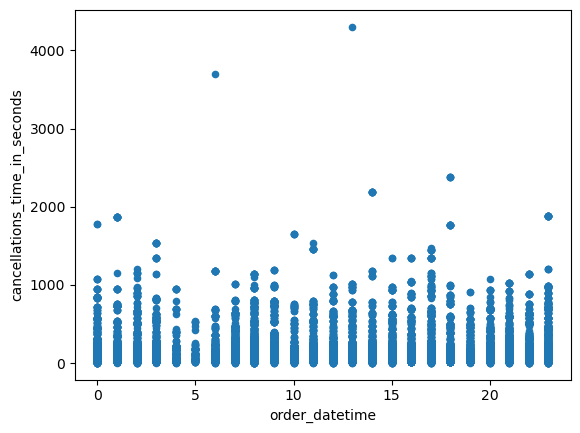

In [175]:
#plotting a scatter plot to check for outliers 
df.plot(kind='scatter', x='order_datetime', y='cancellations_time_in_seconds')

- There are a few Outliers on the displayed plot between 3500 and 5000 seconds 

In [178]:
#checking rows which has cancellation time greater than 2000
df[df['cancellations_time_in_seconds'] > 2000]

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,cancellations_time_in_seconds,offer_id,is_driver_assigned,order_status
11815,14,-0.966768,51.442815,538.0,3000557285679,2190.0,300050762018,Yes,Client Cancelled
11816,14,-0.966768,51.442815,538.0,3000557285679,2190.0,300050762022,Yes,Client Cancelled
11817,14,-0.966768,51.442815,538.0,3000557285679,2190.0,300050762031,Yes,Client Cancelled
11818,14,-0.966768,51.442815,538.0,3000557285679,2190.0,300050762028,Yes,Client Cancelled
11819,14,-0.966768,51.442815,538.0,3000557285679,2190.0,300050762013,Yes,Client Cancelled
11820,14,-0.966768,51.442815,538.0,3000557285679,2190.0,300050762025,Yes,Client Cancelled
11821,14,-0.966768,51.442815,538.0,3000557285679,2190.0,300050762027,Yes,Client Cancelled
24670,13,-0.978230,51.454575,117.0,3000589207012,4303.0,300051258839,Yes,Client Cancelled
24966,6,-1.002524,51.453284,60.0,3000577775717,3697.0,300050837232,Yes,Client Cancelled
29193,18,-0.956988,51.449547,238.0,3000618075800,2376.0,300051744083,Yes,Client Cancelled


In [180]:
#dropping rows where cancellation time is greater than 2000s
df = df[df['cancellations_time_in_seconds'] < 2000].reset_index(drop=True)

<Axes: xlabel='order_datetime', ylabel='cancellations_time_in_seconds'>

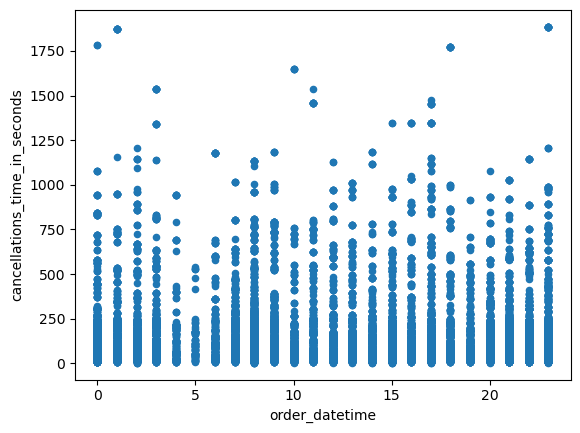

In [184]:
#new plot after removing the outliers
df.plot(kind='scatter', x='order_datetime', y='cancellations_time_in_seconds')	

In [187]:
#grouping by order_datetime and is_driver_assigned with average cancellation time
avg_seconds = df.groupby(by=['order_datetime','is_driver_assigned'])['cancellations_time_in_seconds'].mean()

In [189]:
#making a pivot table of the grouped data
avg_seconds_table = avg_seconds.reset_index().pivot(index='order_datetime', 
                                columns='is_driver_assigned',
                                values='cancellations_time_in_seconds')
avg_seconds_table.head()

is_driver_assigned,No,Yes
order_datetime,,
0,115.126437,276.082822
1,100.593997,296.312081
2,121.305461,301.466667
3,129.182301,368.682051
4,100.733333,245.250000


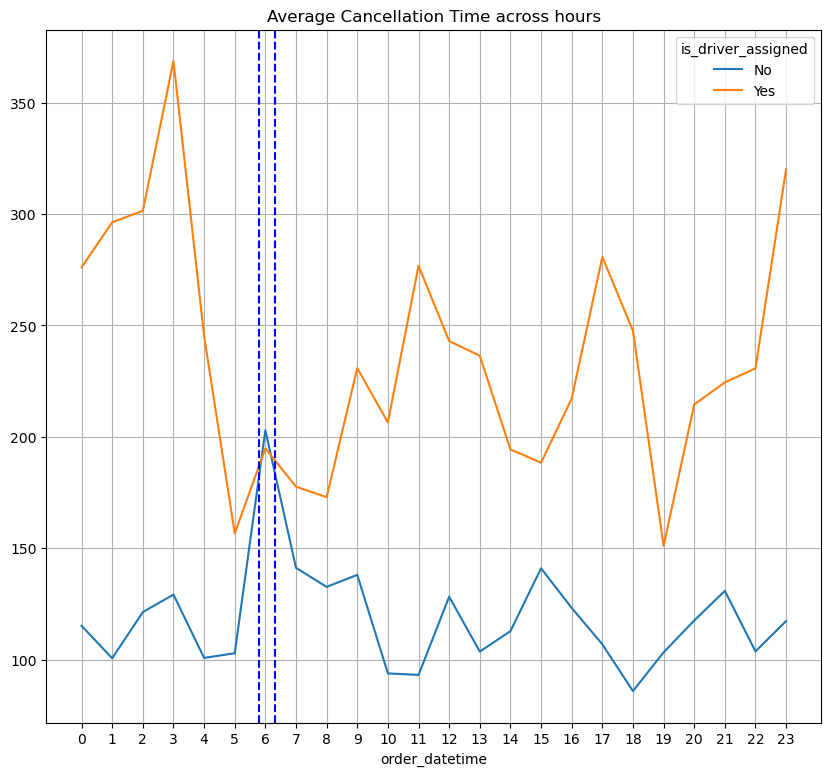

In [199]:
#plotting the pivot table
avg_seconds_table.plot(xticks=range(0,24),
                       figsize=(10,9),
                       title='Average Cancellation Time across hours',
                      grid=True)
plt.axvline(x =5.8, color = 'b',ls= '--')
plt.axvline(x =6.3, color = 'b',ls= '--');

- The average cancellation time for driver assigned orders is higher than orders 
that werent assigned by a driver. However, this doesn’t necessarily imply driver delays — longer cancellation times might instead reflect late driver assignment or perceived inactivity in the app. To confirm this, we would need additional data such as the exact timestamp of when each driver was assigned. Currently, we only know whether a driver was assigned or not, but not when.

### Assignment 4
Plot the distribution of average ETA by hours. How can this plot be explained?

In [203]:
df

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,cancellations_time_in_seconds,offer_id,is_driver_assigned,order_status
0,18,-0.978916,51.456173,60.0,3000583041974,198.0,300050983403,Yes,Client Cancelled
1,20,-0.950385,51.456843,NaN,3000583116437,128.0,300050986179,No,Client Cancelled
2,20,-0.950385,51.456843,NaN,3000583116437,128.0,300050986174,No,Client Cancelled
3,20,-0.950385,51.456843,NaN,3000583116437,128.0,300050986180,No,Client Cancelled
4,12,-0.969520,51.455544,477.0,3000582891479,46.0,300050976275,Yes,Client Cancelled
...,...,...,...,...,...,...,...,...,...
21777,12,-0.975372,51.457846,NaN,3000597886155,43.0,300051590196,No,Client Cancelled
21778,12,-0.975372,51.457846,NaN,3000597886140,44.0,300051590176,No,Client Cancelled
21779,13,-0.975372,51.457846,NaN,3000599186906,36.0,300051648809,No,Client Cancelled
21780,13,-0.972926,51.457693,60.0,3000599187034,34.0,300051648910,Yes,Client Cancelled


<Axes: xlabel='order_datetime', ylabel='m_order_eta'>

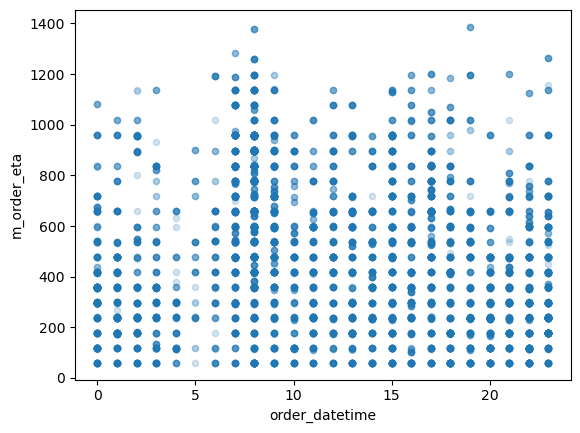

In [209]:
#curious about the distribution of the order eta on a scatter plot.
df.plot(kind='scatter', x='order_datetime',y='m_order_eta',alpha=0.2)

<Axes: title={'center': 'Average ETA By Hours'}, xlabel='order_datetime'>

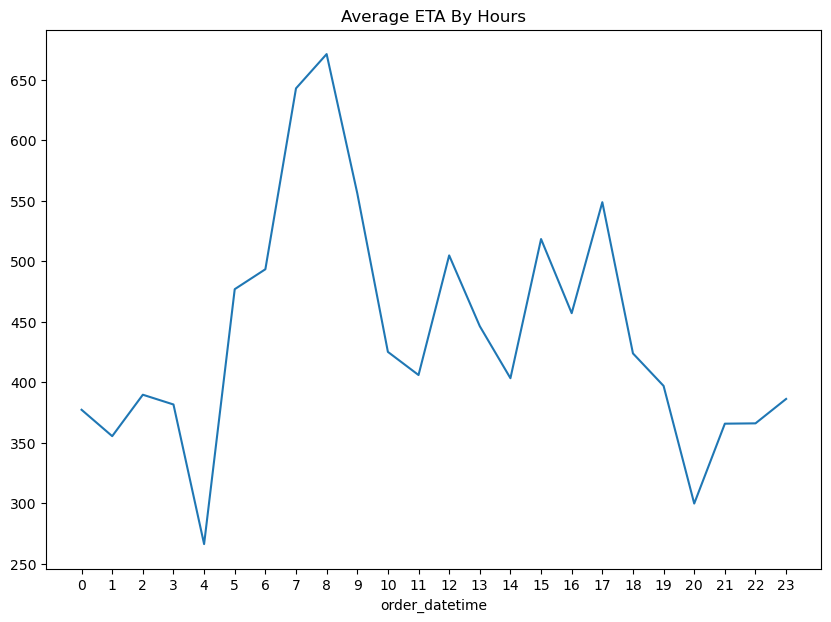

In [212]:
#plotting the average ETA by hour.
(df.groupby('order_datetime')['m_order_eta'].mean()).plot(kind='line', xticks=range(0,24),figsize=(10,7), title='Average ETA By Hours')

- There are extremely high ETA spikes between 7–9 AM, exceeding 600 seconds, likely due to traffic congestion, low supply, or inaccurate predictions.

- ETA remains more stable between 1 PM and 6 PM, though it trends upward slightly later in the day**